In [1]:
# Cell 1 - Import libraries and load dataset

import pandas as pd
import numpy as np

# Load dataset
file_path = "/kaggle/input/studies-career-recommendation-dataset/student-scores-6k.csv"
df = pd.read_csv(file_path)

# Display first few rows and dataset info
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (6000, 17)


,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Social Network Studies,84,77,65,65,80,74,76


In [2]:
# Cell 2 - Preprocessing

# Drop unnecessary columns
df = df.drop(columns=['id', 'first_name', 'last_name', 'email'])

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Encode categorical columns (convert text to numbers)
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for column in ['gender', 'part_time_job', 'extracurricular_activities', 'career_aspiration']:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le  # save encoders for inverse transform later

print("\nUnique encoded values per column:")
for column in ['gender', 'part_time_job', 'extracurricular_activities', 'career_aspiration']:
    print(f"{column}: {df[column].unique()}")

# Display first few rows after encoding
df.head()


Missing values per column:
gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64

Unique encoded values per column:
gender: [1 0]
part_time_job: [0 1]
extracurricular_activities: [0 1]
career_aspiration: [ 9  6  8  1 12 13 15  3 11  2 16  0  5  4  7 14 10]


,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,0,3,0,27,9,73,81,93,97,63,80,87
1,0,0,2,0,47,6,90,86,96,100,90,88,90
2,0,0,9,1,13,8,81,97,95,96,65,77,94
3,0,0,5,0,3,1,71,74,88,80,89,63,86
4,1,0,5,0,10,12,84,77,65,65,80,74,76


In [3]:
# Cell 3 - Feature/Target Split and Train-Test Division

from sklearn.model_selection import train_test_split

# Features (input) — everything except career_aspiration
X = df.drop(columns=['career_aspiration'])

# Target (output) — career_aspiration
y = df['career_aspiration']

# Split data into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)


Training Set Shape: (4800, 12)
Testing Set Shape: (1200, 12)


In [4]:
# Cell 4 - Train Random Forest Model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the model
rf_model = RandomForestClassifier(
    n_estimators=200,   # number of trees
    max_depth=12,       # prevent overfitting
    random_state=42
)




In [5]:
# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=12, n_estimators=200, random_state=42)

In [6]:
# Predictions
y_pred = rf_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 85.92%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.66      0.78        76
           1       1.00      0.97      0.99        40
           2       0.90      0.76      0.82       101
           3       0.98      1.00      0.99       185
           4       1.00      0.63      0.78        41
           5       1.00      0.68      0.81        34
           6       1.00      0.94      0.97        71
           7       0.88      1.00      0.94        38
           8       1.00      0.81      0.90        37
           9       0.85      0.99      0.92        83
          10       0.94      0.94      0.94        50
          11       1.00      0.65      0.79        23
          12       0.97      0.75      0.84       134
          13       0.59      0.99      0.74       189
          14       1.00      0.45      0.62        44
          15       1.00      0.97      0.99        35
          16       1.00      0.53 

In [9]:
# Cell 6 - Predict career for a new (dummy) user

# Example user input
user_data = {
    "gender": 1,  # 1=male (as per your label encoding)
    "part_time_job": 0,
    "absence_days": 4,
    "extracurricular_activities": 1,
    "weekly_self_study_hours": 20,
    "math_score": 15,
    "history_score": 70,
    "physics_score": 18,
    "chemistry_score": 92,
    "biology_score": 95,
    "english_score": 10,
    "geography_score": 18
}

# Convert to DataFrame
user_df = pd.DataFrame([user_data])

# Predict encoded class
predicted_class = rf_model.predict(user_df)[0]

# Decode predicted career name
career_label = label_encoders['career_aspiration'].inverse_transform([predicted_class])[0]

print(f"🎓 Recommended Career Path: {career_label}")


🎓 Recommended Career Path: Business Owner


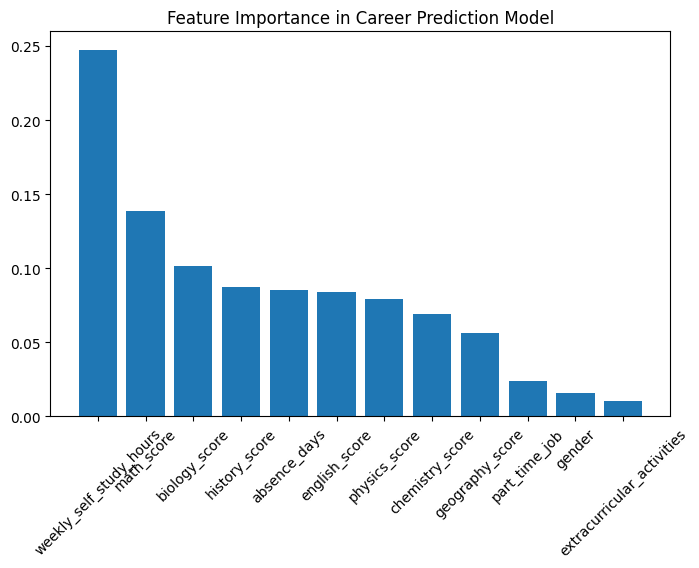

In [10]:
# Cell 7 - Check which features influence predictions most

import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

# Sort by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.title("Feature Importance in Career Prediction Model")
plt.bar(range(len(features)), importances[indices], align="center")
plt.xticks(range(len(features)), [features[i] for i in indices], rotation=45)
plt.show()


In [16]:
print("using xgboost to improve accuracy and efficiency of model")

using xgboost to improve accuracy and efficiency of model


XG Boost

In [11]:
# Cell 8 - Train XGBoost Classifier for Career Prediction

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)




In [12]:
# Train the model
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [13]:
# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate performance
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"🚀 XGBoost Model Accuracy: {accuracy_xgb * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))

🚀 XGBoost Model Accuracy: 97.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        76
           1       1.00      1.00      1.00        40
           2       1.00      0.97      0.98       101
           3       0.97      1.00      0.98       185
           4       1.00      1.00      1.00        41
           5       1.00      0.91      0.95        34
           6       0.96      1.00      0.98        71
           7       1.00      1.00      1.00        38
           8       0.92      0.92      0.92        37
           9       0.97      1.00      0.98        83
          10       1.00      0.94      0.97        50
          11       1.00      1.00      1.00        23
          12       0.98      0.96      0.97       134
          13       0.95      1.00      0.98       189
          14       1.00      0.86      0.93        44
          15       1.00      1.00      1.00        35
          16       1.00 

In [14]:
# Cell 9 - Save the XGBoost model for later inference

import joblib

# Save model
joblib.dump(xgb_model, "career_recommendation_xgb_model.pkl")

# Save label encoders (reuse same ones from before)
joblib.dump(label_encoders, "label_encoders.pkl")

print("✅ XGBoost Model and encoders saved successfully!")

✅ XGBoost Model and encoders saved successfully!


In [15]:
# Cell 10 - Test XGBoost prediction

# Example user input
user_data = {
    "gender": 1,
    "part_time_job": 0,
    "absence_days": 4,
    "extracurricular_activities": 1,
    "weekly_self_study_hours": 20,
    "math_score": 15,
    "history_score": 70,
    "physics_score": 18,
    "chemistry_score": 92,
    "biology_score": 95,
    "english_score": 10,
    "geography_score": 18
}

import pandas as pd
user_df = pd.DataFrame([user_data])

predicted_class = xgb_model.predict(user_df)[0]
career_label = label_encoders['career_aspiration'].inverse_transform([predicted_class])[0]

print(f"🎯 Recommended Career Path (XGBoost): {career_label}")


🎯 Recommended Career Path (XGBoost): Social Network Studies
